NOTEBOOK USED TO TEST CODE

In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

plt.style.use("seaborn-v0_8")

In [ ]:

# Locate all water_calibration.json files
root_dir = r"C:\Data\Water-cal\TESTS-2-18-26"   

json_files = []
for path, dirs, files in os.walk(root_dir):
    for f in files:
        if f == "water_calibration.json":
            json_files.append(os.path.join(path, f))

print(f"Found {len(json_files)} calibration files")


Found 10 calibration files


In [58]:

# Process all calibration files

def load_and_recompute(json_path) -> None:
    with open(json_path, "r") as f:
        data = json.load(f)

    measurements = data["input"]["measurements"]

    # Extract valve_open_time and water_weight
    times = []
    weights = []

    for m in measurements:
        times.append(m["valve_open_time"])
        weights.append(m["water_weight"][0])  # list of length 1

    X = np.array(times).reshape(-1, 1)
    y = np.array(weights)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)

    recomputed_slope = model.coef_[0]
    recomputed_intercept = model.intercept_
    recomputed_r2 = model.score(X, y)

    # Extract original values from JSON
    original_slope = data["output"]["slope"]
    original_intercept = data["output"]["offset"]
    original_r2 = data["output"]["r2"]

    df = pd.DataFrame({
        "valve_open_time": times,
        "water_weight": weights
    })

    return {
        "df": df,
        "recomputed_slope": recomputed_slope,
        "recomputed_intercept": recomputed_intercept,
        "recomputed_r2": recomputed_r2,
        "original_slope": original_slope,
        "original_intercept": original_intercept,
        "original_r2": original_r2
    }



results = []

for file in json_files:
    r = load_and_recompute(file)
    folder_name = file.split("\\")[-2]
    r["name"] = folder_name.split('_')[0]
    full_date = folder_name.split('_')[-1]
    r["date"] = full_date.split('T')[0]
    r["rig"] = folder_name[:3]
    r["file"] = folder_name
    results.append(r)

results
# Display comparison of original vs recomputed values
for res in results:
    print(f"Name: {res['name']}    Date: {r["date"]}")
    print(f"            Original | 1/recomp | Recomputed ")    
    print(f" slope:     {res['original_slope']:.5f}  | {1/res['recomputed_slope']:.5f}  |  {res['recomputed_slope']:.2f}")
    print(f" intercept: {res['original_intercept']:.4f}  |          |  {res['recomputed_intercept']:.4f}   ")
    print(f" R²:        {res['original_r2']:.5f}  |          |  {res['recomputed_r2']:.5f}")
    print("-" * 50)


Name: 12D-0.1    Date: 2026-01-15
            Original | 1/recomp | Recomputed 
 slope:     0.21974  | 0.39055  |  2.56
 intercept: -0.0977  |          |  0.6651   
 R²:        0.56264  |          |  0.56264
--------------------------------------------------
Name: 12D-0.25    Date: 2026-01-15
            Original | 1/recomp | Recomputed 
 slope:     0.09428  | 0.09445  |  10.59
 intercept: -0.0222  |          |  0.2378   
 R²:        0.99826  |          |  0.99826
--------------------------------------------------
Name: 12D-1    Date: 2026-01-15
            Original | 1/recomp | Recomputed 
 slope:     0.12698  | 0.12910  |  7.75
 intercept: -0.0480  |          |  0.3924   
 R²:        0.98359  |          |  0.98359
--------------------------------------------------
Name: 12D-Normal    Date: 2026-01-15
            Original | 1/recomp | Recomputed 
 slope:     0.08589  | 0.08603  |  11.62
 intercept: -0.0191  |          |  0.2245   
 R²:        0.99838  |          |  0.99838
-----------

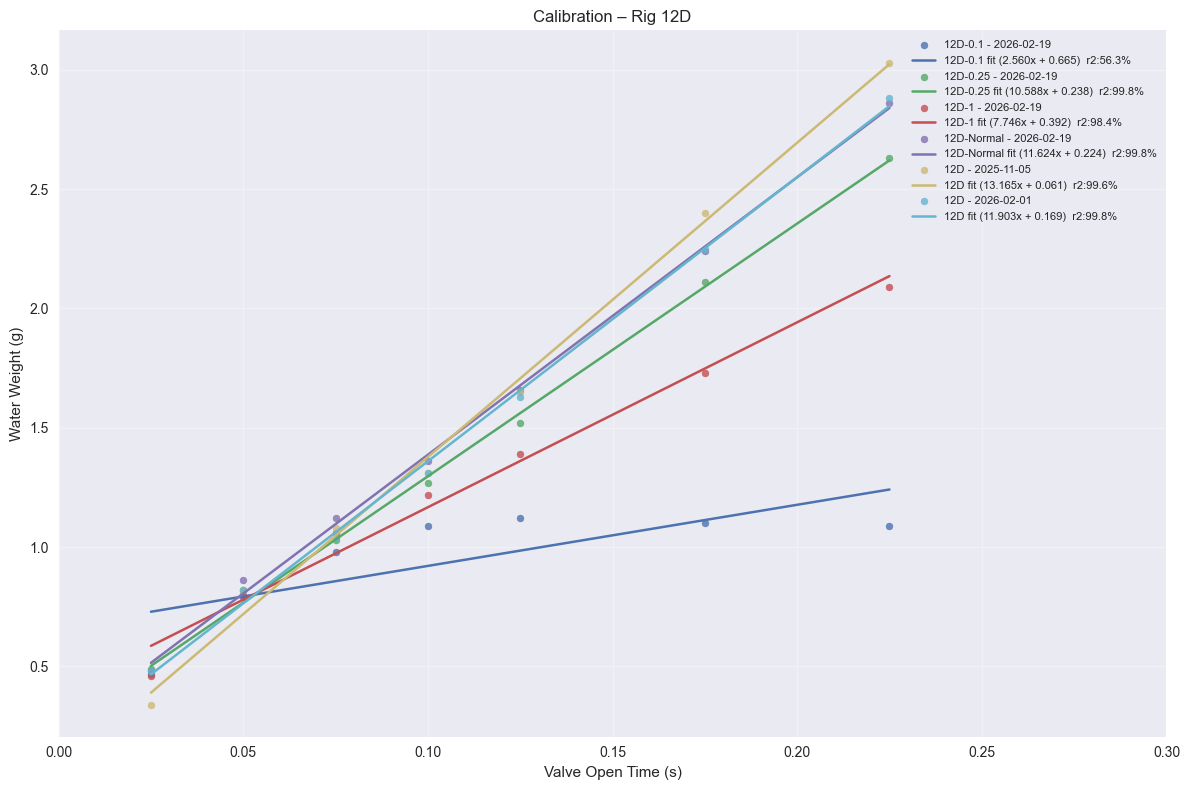

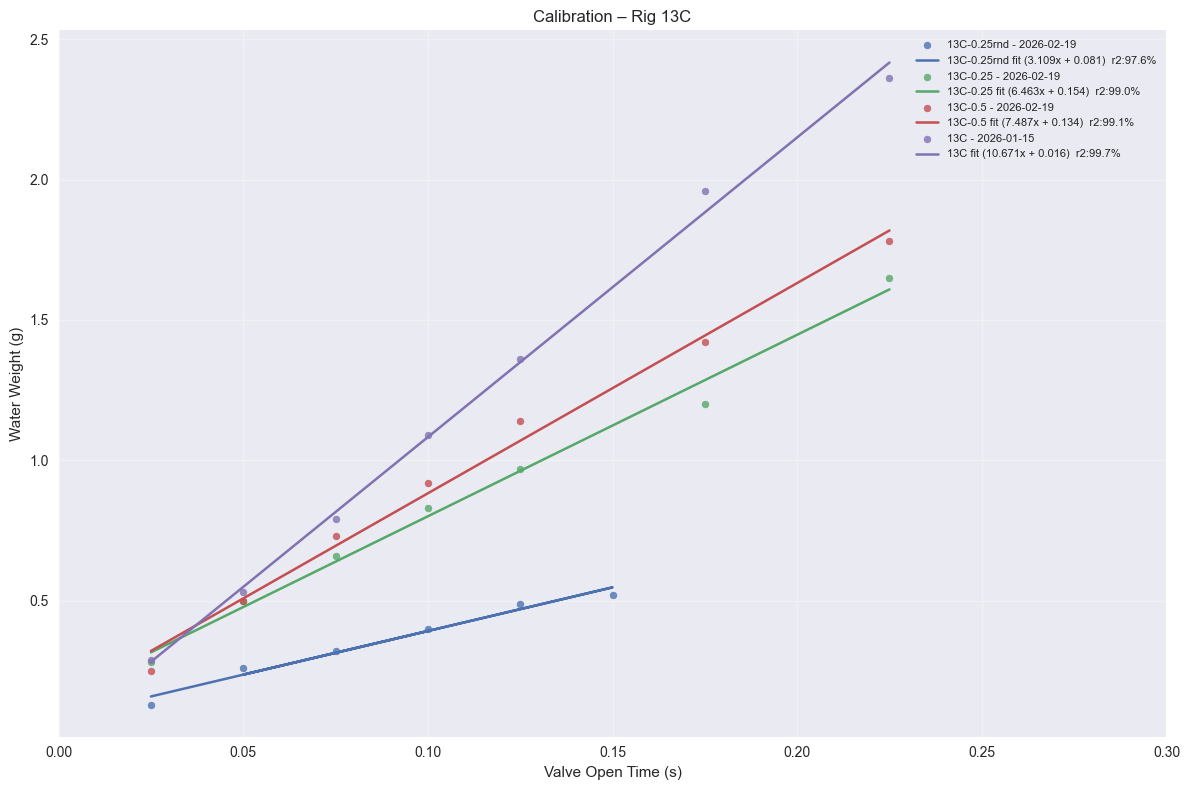

In [ ]:
# # Plot each calibration curve
# for r in results:
#     df = r["df"]
#     slope = r["recomputed_slope"]
#     intercept = r["recomputed_intercept"]

#     x = df["valve_open_time"]
#     y_pred = slope * x + intercept

#     plt.figure(figsize=(6,4))
#     plt.scatter(df["valve_open_time"], df["water_weight"], label="Measured")
#     plt.plot(x, y_pred, color="red", label=f"Fit: y={slope:.4f}x + {intercept:.4f}")
#     plt.title(f"Calibration: {r['file']}")
#     plt.xlabel("Valve Open Time (s)")
#     plt.ylabel("Water Weight (g)")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
    


# Plot all calibration curves by rig
rig_groups = {}
for r in results:
    rig = r.get("rig", "Unknown")
    rig_groups.setdefault(rig, []).append(r)

# One figure per rig
for rig, group in rig_groups.items():
    plt.figure(figsize=(12, 8))

    for r in group:
        df = r["df"]
        slope = float(r["recomputed_slope"])
        intercept = float(r["recomputed_intercept"])
        r2 = float(r["recomputed_r2"])
        x = df["valve_open_time"]
        y = df["water_weight"]
        y_pred = slope * x + intercept
        plt.scatter(x, y, s=25, alpha=0.8, label=f"{r['name']} - {r['date']}")
        plt.plot(x, y_pred, linewidth=1.8, label=f"{r['name']} fit ({slope:.3f}x + {intercept:.3f})  r2:{r2*100:.1f}%")

    plt.xlim(0, 0.3)
    plt.title(f"Calibration – Rig {rig}")
    plt.xlabel("Valve Open Time (s)")
    plt.ylabel("Water Weight (g)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



In [ ]:

# Summary plot of slopes across directories

plt.figure(figsize=(8,4))

slopes = [r["recomputed_slope"] for r in results]
labels = [os.path.basename(os.path.dirname(r["file"])) for r in results]

plt.bar(labels, slopes)
plt.ylabel("Slope (g per second)")
plt.title("Recomputed Slopes Across Calibration Files")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
